### FED COMPARISON

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import wilcoxon, mannwhitneyu


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

os.makedirs('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-comparison', exist_ok=True)


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['role'] = df1['track_id'].map({0: 'starved', 1: 'fed'})
df1 = df1[df1['role'] == 'fed']
df1['condition'] = 'fed(f-s)'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['condition'] = 'fed(f-f)'

df = pd.concat([df1, df2], ignore_index=True)



df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df = df.sort_values(['condition', 'file', 'track_id', 'rel_frame'])


metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['condition', 'file', 'track_id', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

# Average larvae within each file before stats, so each recording contributes once.
first_interaction_file = (
    first_interaction
    .groupby(['condition', 'file', 'interaction_group', 'rel_frame'])[metrics]
    .mean()
    .reset_index()
)


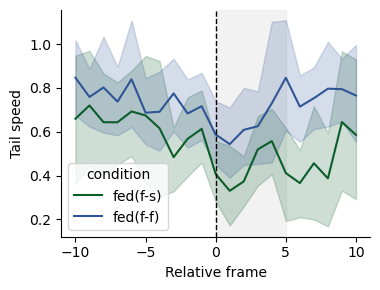

In [2]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='condition',
    hue_order=['fed(f-s)', 'fed(f-f)'],
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    errorbar=('ci', 95)
)

plt.axvspan(0, 5, color='0.9', alpha=0.5, zorder=0)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('Tail speed')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-comparison/speed.pdf', format='pdf')
plt.show()


In [3]:
# Frames 1-5: average tail speed per file, then independent fed(f-s) vs fed(f-f) test
speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_5)
print(speed_1_5.mean())

stat, p = mannwhitneyu(speed_1_5['fed(f-s)'].dropna(), speed_1_5['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-5, fed(f-s) vs fed(f-f): U={stat:.3g}, p={p:.3g}")


condition,fed(f-f),fed(f-s)
file,,
2026-04-28_12-06-18_td8.tracks.feather,0.525864,NaN
2026-04-28_12-11-39_td10.tracks.feather,0.441229,NaN
2026-04-28_12-17-10_td5.tracks.feather,NaN,0.311840
2026-04-28_15-10-10_td6.tracks.feather,0.528105,NaN
2026-05-11_11-19-24_td4.tracks.feather,NaN,0.703004
2026-05-12_14-40-12_td9.tracks.feather,0.598184,NaN
2026-05-12_14-43-05_td7.tracks.feather,0.683013,NaN
2026-05-12_14-44-29_td4.tracks.feather,NaN,0.299530
2026-05-18_11-50-46_td8.tracks.feather,0.499041,NaN


condition
fed(f-f)    0.670651
fed(f-s)    0.438384
dtype: float64
Mann-Whitney U test, frames 1-5, fed(f-s) vs fed(f-f): U=14, p=0.0171


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_16068/2710205786.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


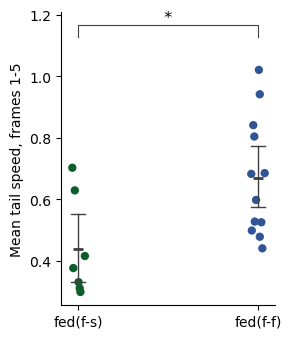

In [4]:
# Plot the values used in the frames 1-5 speed test
speed_1_5_plot = speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['fed(f-s)', 'fed(f-f)'],
    var_name='condition',
    value_name='speed_tail'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['fed(f-s)', 'fed(f-f)'],
    hue='condition',
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['fed(f-s)', 'fed(f-f)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = speed_1_5_plot['speed_tail'].max()
ymin = speed_1_5_plot['speed_tail'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean tail speed, frames 1-5')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-comparison/speed_mean.pdf', format='pdf')
plt.show()


In [5]:
# Frames 1-5 after contact compared with frames -5 to -1 before contact, tail speed
pre_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(-5, -1)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

post_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

change_speed_1_5 = post_speed_1_5 - pre_speed_1_5

display(pd.concat({'pre': pre_speed_1_5, 'post': post_speed_1_5, 'post_minus_pre': change_speed_1_5}, axis=1))
print('Mean pre:')
print(pre_speed_1_5.mean())
print('\nMean post:')
print(post_speed_1_5.mean())
print('\nMean post - pre:')
print(change_speed_1_5.mean())

fed_fs_pairs = pd.concat([pre_speed_1_5['fed(f-s)'], post_speed_1_5['fed(f-s)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_fs = wilcoxon(fed_fs_pairs['pre'], fed_fs_pairs['post'])
print(f"fed(f-s) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_fs:.3g}")

fed_ff_pairs = pd.concat([pre_speed_1_5['fed(f-f)'], post_speed_1_5['fed(f-f)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_ff = wilcoxon(fed_ff_pairs['pre'], fed_ff_pairs['post'])
print(f"fed(f-f) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_ff:.3g}")

stat, change_p = mannwhitneyu(change_speed_1_5['fed(f-s)'].dropna(), change_speed_1_5['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Change score, tail speed fed(f-s) vs fed(f-f), frames 1-5: U={stat:.3g}, p={change_p:.3g}")


pre                post  \
condition                                fed(f-f)  fed(f-s)  fed(f-f)   
file                                                                    
2026-04-28_12-06-18_td8.tracks.feather   0.462360       NaN  0.525864   
2026-04-28_12-11-39_td10.tracks.feather  1.049770       NaN  0.441229   
2026-04-28_12-17-10_td5.tracks.feather        NaN  0.234589       NaN   
2026-04-28_15-10-10_td6.tracks.feather   0.830654       NaN  0.528105   
2026-05-11_11-19-24_td4.tracks.feather        NaN  0.676575       NaN   
2026-05-12_14-40-12_td9.tracks.feather   0.994959       NaN  0.598184   
2026-05-12_14-43-05_td7.tracks.feather   0.888120       NaN  0.683013   
2026-05-12_14-44-29_td4.tracks.feather        NaN  0.778907       NaN   
2026-05-18_11-50-46_td8.tracks.feather   0.535840       NaN  0.499041   
2026-05-18_11-54-47_td10.tracks.feather  0.901716       NaN  0.685480   
2026-05-18_15-07-28_td20.tracks.feather  0.718987       NaN  1.020764   
2026-05-19_12-25-59_td17.tracks.feather       NaN  0.490206       NaN   
2026-05-19_12-27-40_td7.tracks.feather   0.420248       NaN  0.804411   
2026-06-05_12-00-53_td7.tracks.feather   0.630057       NaN  0.478862   
2026-06-05_12-02-47_td6.tracks.feather   0.377963       NaN  0.941589   
2026-06-22_11-57-42_td4.tracks.feather        NaN  0.901595       NaN   
2026-06-22_11-59-31_td5.tracks.feather        NaN  0.748890       NaN   
2026-06-23_15-44-45_td4.tracks.feather   0.714814       NaN  0.841268   
2026-06-23_15-48-53_td5.tracks.feather        NaN  0.306083       NaN   

                                                  post_minus_pre            
condition                                fed(f-s)       fed(f-f)  fed(f-s)  
file                                                                        
2026-04-28_12-06-18_td8.tracks.feather        NaN       0.063504       NaN  
2026-04-28_12-11-39_td10.tracks.feather       NaN      -0.608541       NaN  
2026-04-28_12-17-10_td5.tracks.feather   0.311840            NaN  0.077251  
2026-04-28_15-10-10_td6.tracks.feather        NaN      -0.302548       NaN  
2026-05-11_11-19-24_td4.tracks.feather   0.703004            NaN  0.026429  
2026-05-12_14-40-12_td9.tracks.feather        NaN      -0.396775       NaN  
2026-05-12_14-43-05_td7.tracks.feather        NaN      -0.205106       NaN  
2026-05-12_14-44-29_td4.tracks.feather   0.299530            NaN -0.479378  
2026-05-18_11-50-46_td8.tracks.feather        NaN      -0.036800       NaN  
2026-05-18_11-54-47_td10.tracks.feather       NaN      -0.216236       NaN  
2026-05-18_15-07-28_td20.tracks.feather       NaN       0.301777       NaN  
2026-05-19_12-25-59_td17.tracks.feather  0.331484            NaN -0.158722  
2026-05-19_12-27-40_td7.tracks.feather        NaN       0.384163       NaN  
2026-06-05_12-00-53_td7.tracks.feather        NaN      -0.151195       NaN  
2026-06-05_12-02-47_td6.tracks.feather        NaN       0.563626       NaN  
2026-06-22_11-57-42_td4.tracks.feather   0.377118            NaN -0.524477  
2026-06-22_11-59-31_td5.tracks.feather   0.416257            NaN -0.332633  
2026-06-23_15-44-45_td4.tracks.feather        NaN       0.126454       NaN  
2026-06-23_15-48-53_td5.tracks.feather   0.629456            NaN  0.323373

Mean pre:
condition
fed(f-f)    0.710457
fed(f-s)    0.590978
dtype: float64

Mean post:
condition
fed(f-f)    0.670651
fed(f-s)    0.438384
dtype: float64

Mean post - pre:
condition
fed(f-f)   -0.039806
fed(f-s)   -0.152594
dtype: float64
fed(f-s) pre vs post, tail speed frames 1-5: W=7, p=0.297
fed(f-f) pre vs post, tail speed frames 1-5: W=32, p=0.622
Change score, tail speed fed(f-s) vs fed(f-f), frames 1-5: U=34, p=0.536


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_16068/258788794.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


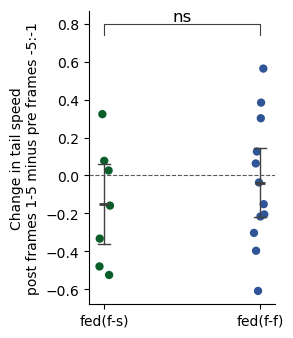

In [6]:
# Plot the values used in the frames 1-5 speed change-score test
change_speed_1_5_plot = change_speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['fed(f-s)', 'fed(f-f)'],
    var_name='condition',
    value_name='speed_change'
)

if change_p < 0.001:
    stars = '***'
elif change_p < 0.01:
    stars = '**'
elif change_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['fed(f-s)', 'fed(f-f)'],
    hue='condition',
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['fed(f-s)', 'fed(f-f)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

plt.axhline(0, color='0.35', linewidth=0.8, linestyle='--')

ymax = change_speed_1_5_plot['speed_change'].max()
ymin = change_speed_1_5_plot['speed_change'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Change in tail speed\npost frames 1-5 minus pre frames -5:-1')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-comparison/speed_baseline_change.pdf', format='pdf')
plt.show()


In [7]:
# Test whether each condition changes from before to after contact, frames 1-5
fed_fs_pairs = pd.concat([pre_speed_1_5['fed(f-s)'], post_speed_1_5['fed(f-s)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_fs = wilcoxon(fed_fs_pairs['pre'], fed_fs_pairs['post'])
print(f"fed(f-s) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_fs:.3g}")
print(f"fed(f-s) mean change: {change_speed_1_5['fed(f-s)'].mean():.3g}")

fed_ff_pairs = pd.concat([pre_speed_1_5['fed(f-f)'], post_speed_1_5['fed(f-f)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_ff = wilcoxon(fed_ff_pairs['pre'], fed_ff_pairs['post'])
print(f"fed(f-f) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_ff:.3g}")
print(f"fed(f-f) mean change: {change_speed_1_5['fed(f-f)'].mean():.3g}")


fed(f-s) pre vs post, tail speed frames 1-5: W=7, p=0.297
fed(f-s) mean change: -0.153
fed(f-f) pre vs post, tail speed frames 1-5: W=32, p=0.622
fed(f-f) mean change: -0.0398


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_16068/3724162302.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_16068/3724162302.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


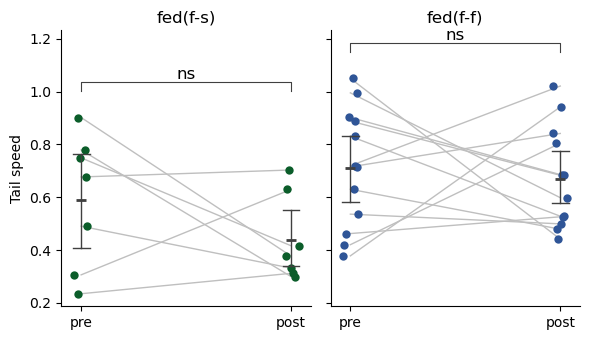

In [8]:
# Plot pre vs post tail speed within each condition, frames 1-5
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

for ax, condition, color, test_p in zip(
    axes,
    ['fed(f-s)', 'fed(f-f)'],
    ['#0B5D2A', '#2F5597'],
    [p_fed_fs, p_fed_ff]
):
    plot_data = pd.DataFrame({
        'file': pre_speed_1_5.index,
        'pre': pre_speed_1_5[condition],
        'post': post_speed_1_5[condition]
    }).dropna()
    long_plot_data = plot_data.melt(
        id_vars='file',
        value_vars=['pre', 'post'],
        var_name='time',
        value_name='speed_tail'
    )

    if test_p < 0.001:
        stars = '***'
    elif test_p < 0.01:
        stars = '**'
    elif test_p < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    for _, row in plot_data.iterrows():
        ax.plot([0, 1], [row['pre'], row['post']], color='0.75', linewidth=1, zorder=1)

    sns.stripplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        color=color,
        size=6,
        jitter=0.04,
        ax=ax,
        zorder=2
    )

    sns.pointplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        errorbar=('ci', 95),
        color='0.25',
        markers='_',
        linestyles='none',
        capsize=0.08,
        err_kws={'linewidth': 1},
        join=False,
        ax=ax
    )

    ymax = long_plot_data['speed_tail'].max()
    ymin = long_plot_data['speed_tail'].min()
    y_range = ymax - ymin if ymax > ymin else 1
    y = ymax + y_range * 0.15
    h = y_range * 0.05
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
    ax.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

    ax.set_title(condition)
    ax.set_xlabel('')
    ax.set_ylabel('Tail speed' if condition == 'fed(f-s)' else '')

sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-comparison/speed_baseline_change_within_condition.pdf', format='pdf')
plt.show()


In [9]:
# Frames 1-10: average tail speed per file, then independent fed(f-s) vs fed(f-f) test
speed_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_10)
print(speed_1_10.mean())

stat, p = mannwhitneyu(speed_1_10['fed(f-s)'].dropna(), speed_1_10['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-10, fed(f-s) vs fed(f-f): U={stat:.3g}, p={p:.3g}")


condition,fed(f-f),fed(f-s)
file,,
2026-04-28_12-06-18_td8.tracks.feather,0.697377,NaN
2026-04-28_12-11-39_td10.tracks.feather,0.552430,NaN
2026-04-28_12-17-10_td5.tracks.feather,NaN,0.440079
2026-04-28_15-10-10_td6.tracks.feather,0.668003,NaN
2026-05-11_11-19-24_td4.tracks.feather,NaN,0.707107
2026-05-12_14-40-12_td9.tracks.feather,0.645788,NaN
2026-05-12_14-43-05_td7.tracks.feather,0.570078,NaN
2026-05-12_14-44-29_td4.tracks.feather,NaN,0.239194
2026-05-18_11-50-46_td8.tracks.feather,0.655330,NaN


condition
fed(f-f)    0.717666
fed(f-s)    0.463065
dtype: float64
Mann-Whitney U test, frames 1-10, fed(f-s) vs fed(f-f): U=10, p=0.00524


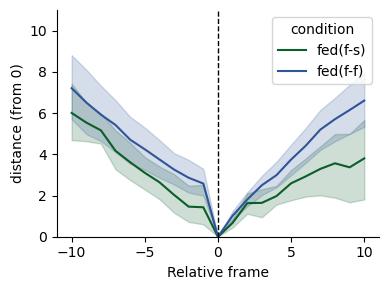

In [10]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='condition',
    hue_order=['fed(f-s)', 'fed(f-f)'],
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    errorbar=('ci', 95)
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('distance (from 0)')
sns.despine()
plt.tight_layout()
plt.ylim(0,11)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-comparison/distance_from_0.pdf', format='pdf')
plt.show()


In [11]:
# Frames 1-5: average distance_from_0 per file, then independent fed(f-s) vs fed(f-f) test
distance_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_5)
print(distance_1_5.mean())

stat, p = mannwhitneyu(distance_1_5['fed(f-s)'].dropna(), distance_1_5['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-5, fed(f-s) vs fed(f-f): U={stat:.3g}, p={p:.3g}")


condition,fed(f-f),fed(f-s)
file,,
2026-04-28_12-06-18_td8.tracks.feather,1.555420,NaN
2026-04-28_12-11-39_td10.tracks.feather,2.573323,NaN
2026-04-28_12-17-10_td5.tracks.feather,NaN,2.101817
2026-04-28_15-10-10_td6.tracks.feather,1.707575,NaN
2026-05-11_11-19-24_td4.tracks.feather,NaN,2.351170
2026-05-12_14-40-12_td9.tracks.feather,2.163309,NaN
2026-05-12_14-43-05_td7.tracks.feather,1.992436,NaN
2026-05-12_14-44-29_td4.tracks.feather,NaN,0.564930
2026-05-18_11-50-46_td8.tracks.feather,2.663494,NaN


condition
fed(f-f)    2.409509
fed(f-s)    1.700687
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-5, fed(f-s) vs fed(f-f): U=17, p=0.0358


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_16068/2166148900.py:35: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


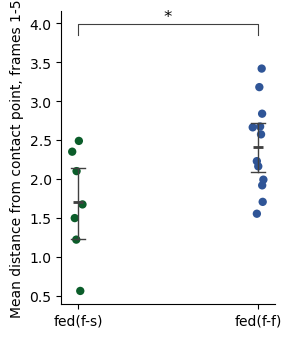

In [12]:
# Plot the values used in the frames 1-5 distance_from_0 test
_, distance_p = mannwhitneyu(distance_1_5['fed(f-s)'].dropna(), distance_1_5['fed(f-f)'].dropna(), alternative='two-sided')

distance_1_5_plot = distance_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['fed(f-s)', 'fed(f-f)'],
    var_name='condition',
    value_name='distance_from_0'
)

if distance_p < 0.001:
    stars = '***'
elif distance_p < 0.01:
    stars = '**'
elif distance_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['fed(f-s)', 'fed(f-f)'],
    hue='condition',
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['fed(f-s)', 'fed(f-f)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_5_plot['distance_from_0'].max()
ymin = distance_1_5_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-5')
sns.despine()
plt.tight_layout()
plt.show()


condition,fed(f-f),fed(f-s)
file,,
2026-04-28_12-06-18_td8.tracks.feather,2.493947,NaN
2026-04-28_12-11-39_td10.tracks.feather,4.332201,NaN
2026-04-28_12-17-10_td5.tracks.feather,NaN,3.450078
2026-04-28_15-10-10_td6.tracks.feather,2.990397,NaN
2026-05-11_11-19-24_td4.tracks.feather,NaN,3.587398
2026-05-12_14-40-12_td9.tracks.feather,2.771458,NaN
2026-05-12_14-43-05_td7.tracks.feather,3.257548,NaN
2026-05-12_14-44-29_td4.tracks.feather,NaN,0.477309
2026-05-18_11-50-46_td8.tracks.feather,4.536210,NaN


condition
fed(f-f)    4.011606
fed(f-s)    2.545040
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-10, fed(f-s) vs fed(f-f): U=17, p=0.0358


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_16068/1394808988.py:47: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


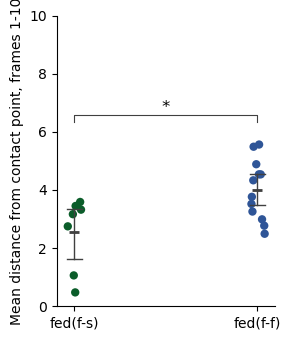

In [13]:
# Frames 1-10: average distance_from_0 per file, then independent fed(f-s) vs fed(f-f) test
distance_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_10)
print(distance_1_10.mean())

stat, p = mannwhitneyu(distance_1_10['fed(f-s)'].dropna(), distance_1_10['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-10, fed(f-s) vs fed(f-f): U={stat:.3g}, p={p:.3g}")

# Plot the values used in the frames 1-10 distance_from_0 test
distance_1_10_plot = distance_1_10.reset_index().melt(
    id_vars='file',
    value_vars=['fed(f-s)', 'fed(f-f)'],
    var_name='condition',
    value_name='distance_from_0'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['fed(f-s)', 'fed(f-f)'],
    hue='condition',
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['fed(f-s)', 'fed(f-f)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_10_plot['distance_from_0'].max()
ymin = distance_1_10_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-10')
plt.ylim(0, 10)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-comparison/distance_from_0_mean.pdf', format='pdf')
plt.show()


In [14]:


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/speed_over_time.csv')
df1['role'] = df1['track'].map({0: 'starved', 1: 'fed'})
df1 = df1[df1['role'] == 'fed']
df1['condition'] = 'fed(f-s)'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/speed_over_time.csv')
df2['condition'] = 'fed(f-f)'

df = pd.concat([df1, df2], ignore_index=True)


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_16068/545345354.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


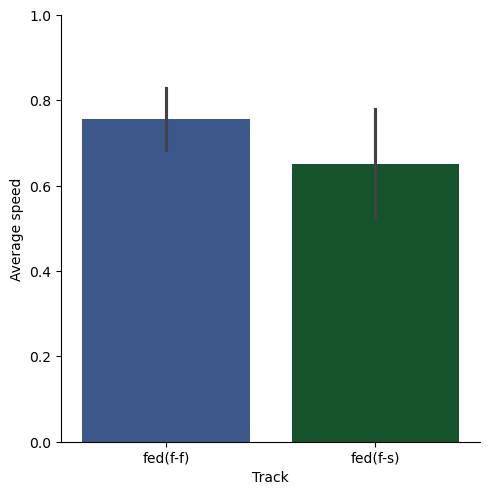

Track fed(f-f) vs track fed(f-s)
Mann-Whitney U = 357
p = 0.004809


In [15]:
speed_summary = (
    df
    .groupby(['file', 'condition'], as_index=False)['speed']
    .mean()
)

track_order = sorted(speed_summary['condition'].dropna().unique())

fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(
    data=speed_summary,
    x='condition',
    y='speed',
    order=track_order,
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    errorbar='sd',
    ax=ax,
)

ax.set_xlabel('Track')
ax.set_ylabel('Average speed')
sns.despine(ax=ax)
plt.tight_layout()
plt.ylim(0, 1)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/fed-comparison/avg_speed.pdf', format='pdf')
plt.show()




track_0 = speed_summary.loc[speed_summary['condition'] == track_order[0], 'speed'].dropna()
track_1 = speed_summary.loc[speed_summary['condition'] == track_order[1], 'speed'].dropna()

test = mannwhitneyu(track_0, track_1, alternative='two-sided')

print(f'Track {track_order[0]} vs track {track_order[1]}')
print(f'Mann-Whitney U = {test.statistic:.4g}')
print(f'p = {test.pvalue:.4g}')